<a href="https://colab.research.google.com/github/raynarah/meu-site/blob/main/conexao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Componentes de validação e busca de hiperparâmetros
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Modelos candidatos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [7]:

# 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS
df = pd.read_csv('/dados_conexao - dados_sinal (1).csv')

coluna_alvo = 'CS'
y = df[coluna_alvo]
X = df.drop(columns=[coluna_alvo])

In [8]:
# 2. ENGENHARIA DE FEATURES (Pré-processamento)
if 'HD' in X.columns:
    X['HD'] = pd.to_datetime(X['HD'])
    X['Hora_do_dia'] = X['HD'].dt.hour
    X = X.drop(columns=['HD'])

colunas_categoricas = ['LC', 'TR', 'OP', 'BA', 'NC', 'CS']
colunas_presentes = [col for col in colunas_categoricas if col in X.columns]
X = pd.get_dummies(X, columns=colunas_presentes, drop_first=True)

In [9]:
# 3. PROTOCOLO EXPERIMENTAL (Divisão dos Dados)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Escalonamento para o KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# 4. AVALIAÇÃO EXPERIMENTAL: AJUSTE DE HIPERPARÂMETROS
print("==================================================")
print("🚀 INICIANDO O GRID SEARCH PARA O RANDOM FOREST...")
print("==================================================")

# Definindo a grade de hiperparâmetros para testar no Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],      # Número de árvores na floresta
    'max_depth': [None, 5, 10],          # Profundidade máxima para controlar overfitting
    'min_samples_split': [2, 5],         # Mínimo de amostras para dividir um nó interno
    'criterion': ['gini', 'entropy']     # Função para medir a qualidade da divisão
}

# Instanciando o modelo base
rf_base = RandomForestClassifier(random_state=42)

# Configurando a busca com Validação Cruzada (cv=3) focando na métrica de AUC-ROC Multiclasse
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=3,
    scoring='roc_auc_ovr_weighted', # Garante otimização focada no AUC-ROC multiclasse
    verbose=1,
    n_jobs=-1
)

# Executando a busca exaustiva nos dados de treino
grid_search_rf.fit(X_train, y_train)

# Recuperando o melhor modelo encontrado com os parâmetros ideais
rf_otimizado = grid_search_rf.best_estimator_

print("\n✨ Melhores Hiperparâmetros Encontrados para o Random Forest:")
print(grid_search_rf.best_params_)

# Dicionário final de modelos para comparação (com o RF já otimizado)
modelos_finais = {
    "KNN (Padrão)": KNeighborsClassifier(),
    "Árvore de Decisão (Padrão)": DecisionTreeClassifier(random_state=42),
    "Random Forest (OTIMIZADO)": rf_otimizado
}

🚀 INICIANDO O GRID SEARCH PARA O RANDOM FOREST...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

✨ Melhores Hiperparâmetros Encontrados para o Random Forest:
{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


--------------------------------------------------
Avaliando desempenho final do modelo: KNN (Padrão)
AUC-ROC Final: 0.6888

Relatório de Classificação Completo:
              precision    recall  f1-score   support

         Bom       0.30      0.33      0.32        21
       Médio       0.28      0.34      0.31        29
        Ruim       0.83      0.68      0.75        50

    accuracy                           0.51       100
   macro avg       0.47      0.45      0.46       100
weighted avg       0.56      0.51      0.53       100



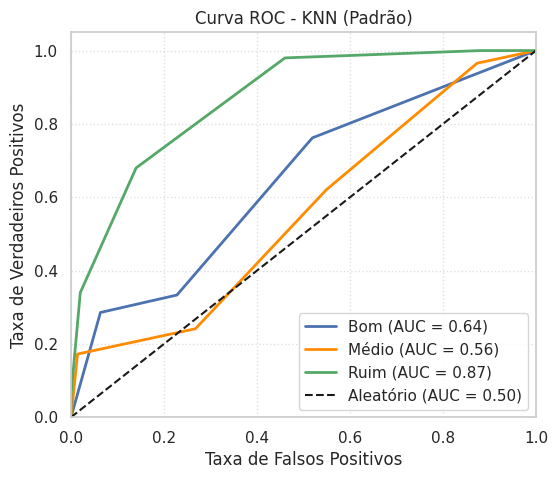

--------------------------------------------------
Avaliando desempenho final do modelo: Árvore de Decisão (Padrão)
AUC-ROC Final: 1.0000

Relatório de Classificação Completo:
              precision    recall  f1-score   support

         Bom       1.00      1.00      1.00        21
       Médio       1.00      1.00      1.00        29
        Ruim       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



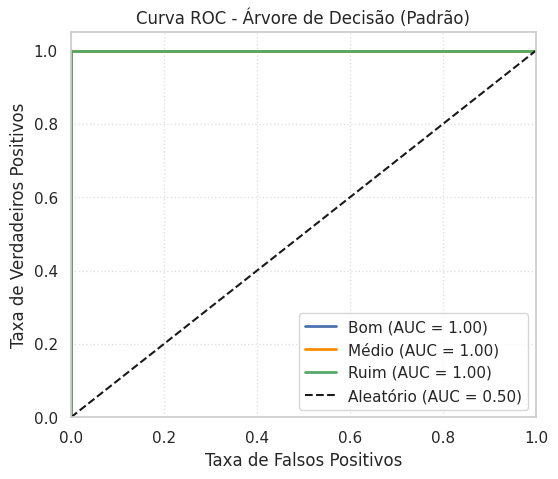

--------------------------------------------------
Avaliando desempenho final do modelo: Random Forest (OTIMIZADO)
AUC-ROC Final: 0.9994

Relatório de Classificação Completo:
              precision    recall  f1-score   support

         Bom       1.00      0.95      0.98        21
       Médio       0.96      0.93      0.95        29
        Ruim       0.96      1.00      0.98        50

    accuracy                           0.97       100
   macro avg       0.98      0.96      0.97       100
weighted avg       0.97      0.97      0.97       100



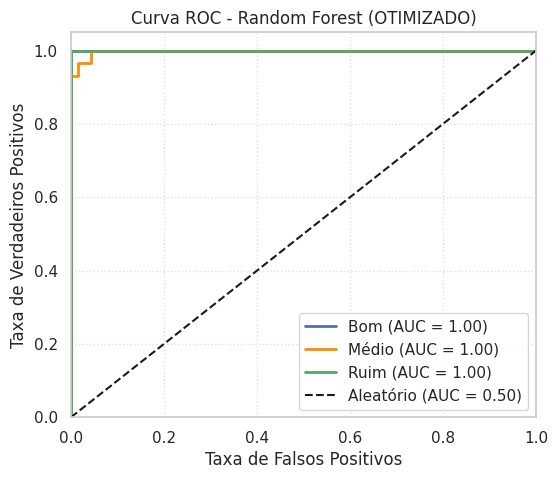

In [13]:
# 5. EXECUÇÃO DOS EXPERIMENTOS E AVALIAÇÃO VISUAL
resultados = {}
classes = list(rf_otimizado.classes_)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

for nome, modelo in modelos_finais.items():
    print("-" * 50)
    print(f"Avaliando desempenho final do modelo: {nome}")

    # Treinamento e Predição respeitando o protocolo do KNN
    if "KNN" in nome:
        modelo.fit(X_train_scaled, y_train)
        y_pred = modelo.predict(X_test_scaled)
        y_prob = modelo.predict_proba(X_test_scaled)
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_prob = modelo.predict_proba(X_test)

    # Cálculo do AUC-ROC Multiclasse (OvR)
    auc_macro = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    resultados[nome] = auc_macro

    print(f"AUC-ROC Final: {auc_macro:.4f}")
    print("\nRelatório de Classificação Completo:")
    print(classification_report(y_test, y_pred))

    # --- GRÁFICO 1: Curva ROC Multiclasse Individual do Modelo ---
    plt.figure(figsize=(6, 5))
    colors = ['b', 'darkorange', 'g']
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score=y_prob[:, i])
        plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{classes[i]} (AUC = {auc(fpr, tpr):.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aleatório (AUC = 0.50)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos')
    plt.title(f'Curva ROC - {nome}')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

--------------------------------------------------
📊 GERANDO GRÁFICO COMPARATIVO FINAL...


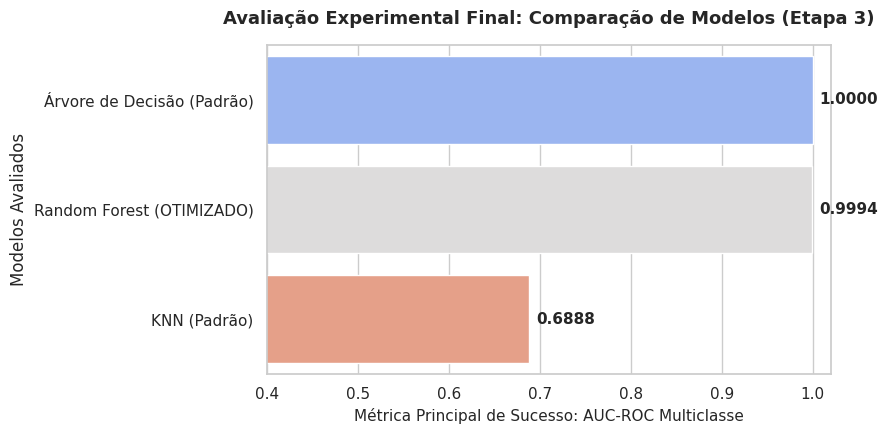

In [12]:
# 6. GRÁFICO COMPARATIVO FINAL
print("-" * 50)
print("📊 GERANDO GRÁFICO COMPARATIVO FINAL...")

df_resultados = pd.DataFrame(list(resultados.items()), columns=['Modelo', 'AUC-ROC']).sort_values(by='AUC-ROC', ascending=False)

plt.figure(figsize=(9, 4.5))
sns.set_theme(style="whitegrid")
grafico = sns.barplot(x='AUC-ROC', y='Modelo', data=df_resultados, palette='coolwarm', hue='Modelo', legend=False)

for container in grafico.containers:
    grafico.bar_label(container, fmt='%.4f', padding=5, fontsize=11, weight='bold')

plt.title('Avaliação Experimental Final: Comparação de Modelos (Etapa 3)', fontsize=13, weight='bold', pad=15)
plt.xlabel('Métrica Principal de Sucesso: AUC-ROC Multiclasse', fontsize=11)
plt.ylabel('Modelos Avaliados')
plt.xlim(0.4, 1.02)
plt.tight_layout()
plt.show()